# ⚠️ Default Risk Analysis

Binary classification task: identify **high-risk** loan applicants likely to default.

**Notebook outline:**
1. Imports & setup
2. Data loading & feature engineering
3. Target variable creation (High_Risk flag)
4. Class distribution & visualisation
5. Feature & preprocessor setup
6. SMOTE oversampling for class imbalance
7. Logistic Regression baseline
8. Random Forest with GridSearch
9. Gradient Boosting
10. Model comparison
11. Feature importance & risk profiling
12. Save best model

## 1. Imports & Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
from sklearn.model_selection import train_test_split

# For handling class imbalance
from imblearn.over_sampling import SMOTE
# Models
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *
from src.utils import *

## 2. Data Loading & Feature Engineering

Load the enriched dataset and engineer all derived features via `src/feature_engineering.py`.

In [4]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")
df = basic_cleaning(df)

In [5]:
df = create_features(df)

## 3. Target Variable Creation

Create the binary `High_Risk` flag: an applicant is labelled **high-risk** when their CIBIL score is low **or** their debt-to-income ratio is high.

In [6]:
df["High_Risk"] = np.where(
    df["Default_History_Count"] > 0,
    1,
    0
)

In [7]:
df["High_Risk"].value_counts()

High_Risk
0    906
1     94
Name: count, dtype: int64

## 4. Class Distribution

Visualise the balance of the `High_Risk` target to understand class imbalance.

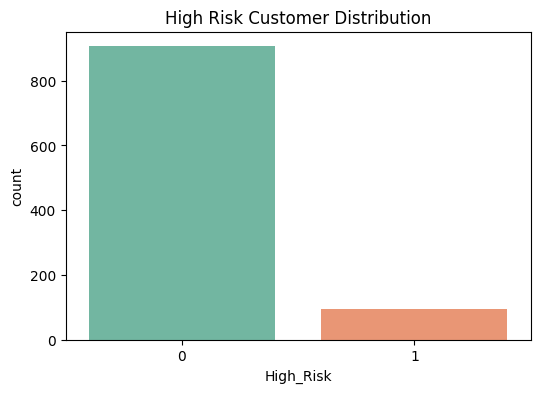

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="High_Risk",
    palette="Set2"
)

plt.title("High Risk Customer Distribution")

plt.show()

## 5. Feature & Preprocessor Setup

Select relevant features, build the preprocessing pipeline, and split data into training and test sets.

In [9]:
features = [
    "Debt_to_Income_Ratio",
    "Existing_EMIs",
    "CIBIL_Score",
    "Employment_Length_Years",
    "Annual_Household_Income",
    "Loan_to_Annual_Income",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "High_Risk"

In [10]:
x, y = select_features(
    df,
    features,
    target
)

In [11]:
num_features, cat_features = get_feature_types(x)

In [12]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print(y_train.value_counts())

High_Risk
0    725
1     75
Name: count, dtype: int64


## 6. Class Imbalance Handling — SMOTE

Apply **Synthetic Minority Oversampling Technique (SMOTE)** to balance the training set before modelling.

In [15]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(
    x_train,
    y_train
)
print(y_train.value_counts())

High_Risk
0    725
1    725
Name: count, dtype: int64


## 7. Logistic Regression (Baseline)

Train a baseline logistic regression on the SMOTE-balanced training data.

In [16]:
lr_pipeline = build_pipeline(
    preprocessor,
    LogisticRegression(random_state=42)
)

In [17]:
lr_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
lr_pred = predict(
    lr_pipeline,
    x_test
)

In [19]:
lr_results = evaluate_classification(
    y_test,
    lr_pred,
    "Logistic Regression"
)
lr_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.66,0.856593,0.66,0.729347


In [20]:
print_classification_report(
    y_test,
    lr_pred
)

              precision    recall  f1-score   support

           0       0.93      0.67      0.78       181
           1       0.14      0.53      0.23        19

    accuracy                           0.66       200
   macro avg       0.54      0.60      0.50       200
weighted avg       0.86      0.66      0.73       200



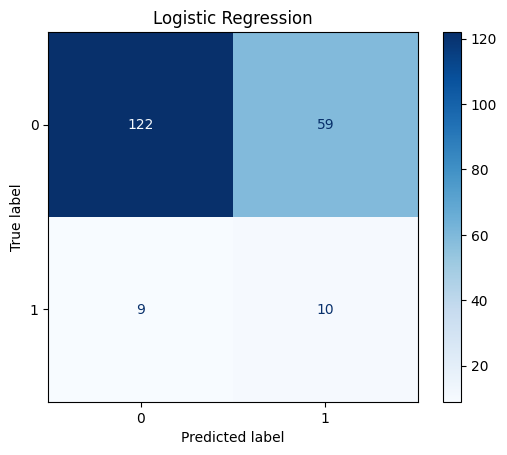

In [21]:
plot_confusion_matrix(
    y_test,
    lr_pred,
    "Logistic Regression"
)

## 8. Random Forest with GridSearchCV

Hyperparameter-tune a Random Forest classifier using grid search with 5-fold CV.

In [22]:
rf_pipeline = build_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

In [23]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [24]:
grid_rf = perform_grid_search(
    pipeline=rf_pipeline,
    parameters=rf_params,
    x_train=x_train,
    y_train=y_train,
    scoring="roc_auc"
)

In [25]:
grid_rf.best_params_

{'classifier__max_depth': 15,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 200}

In [26]:
best_rf = grid_rf.best_estimator_

rf_pred = predict(
    best_rf,
    x_test
)

In [27]:
rf_results = evaluate_classification(
    y_test,
    rf_pred
)

rf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Model,0.75,0.817186,0.75,0.781257


In [28]:
print_classification_report(
    y_test,
    rf_pred
)

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       181
           1       0.06      0.11      0.07        19

    accuracy                           0.75       200
   macro avg       0.48      0.46      0.46       200
weighted avg       0.82      0.75      0.78       200



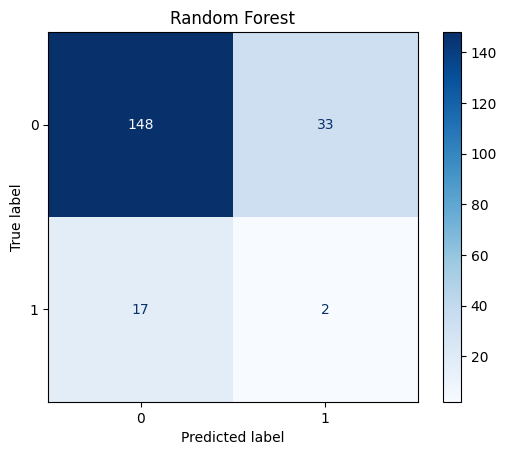

In [29]:
plot_confusion_matrix(
    y_test,
    rf_pred,
    "Random Forest"
)

## 9. Gradient Boosting Classifier

Train a GradientBoostingClassifier and compare its performance with the previous models.

In [30]:
gb_pipeline = build_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=42)
)

In [31]:
gb_pipeline.fit(
    x_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
gb_pred = predict(
    gb_pipeline,
    x_test
)

In [33]:
gb_results = evaluate_classification(
    y_test,
    gb_pred,
    "Gradient Boosting"
)

gb_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.695,0.834973,0.695,0.751794


## 10. Model Comparison

Aggregate all three models' metrics into a single comparison table and plot ROC curves.

In [34]:
comparison = compare_models(
    [lr_results, rf_results, gb_results],
    names=["Logistic Regression", "Random Forest", "Gradient Boosting"]
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
Logistic Regression,Logistic Regression,0.660,0.856593,0.660,0.729347
Random Forest,Model,0.750,0.817186,0.750,0.781257
Gradient Boosting,Gradient Boosting,0.695,0.834973,0.695,0.751794


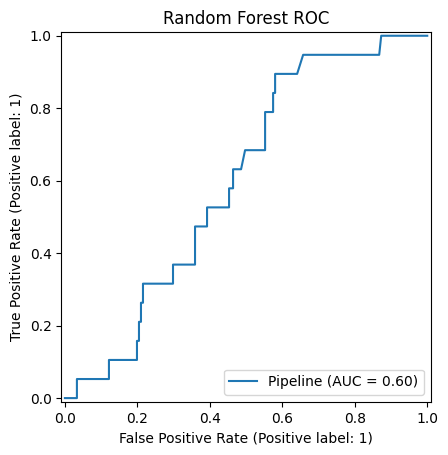

In [35]:
plot_roc_curve(
    best_rf,
    x_test,
    y_test,
    "Random Forest ROC"
)

## 11. Feature Importance & Risk Profiling

Identify the most predictive features and profile the characteristics of high-risk applicants.

In [36]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

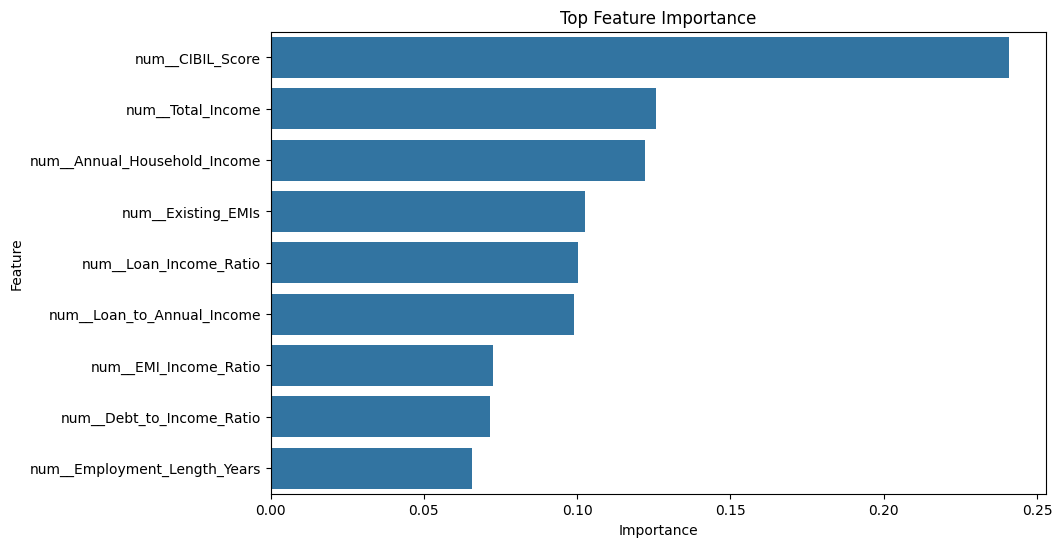

,Feature,Importance
2,num__CIBIL_Score,0.240767
6,num__Total_Income,0.125626
4,num__Annual_Household_Income,0.122000
1,num__Existing_EMIs,0.102642
7,num__Loan_Income_Ratio,0.100286
5,num__Loan_to_Annual_Income,0.098905
8,num__EMI_Income_Ratio,0.072569
0,num__Debt_to_Income_Ratio,0.071511
3,num__Employment_Length_Years,0.065693


In [37]:
feature_importance = plot_feature_importance(

    best_rf,

    feature_names

)

feature_importance.head(10)

In [38]:
high_risk = df[df["High_Risk"] == 1]

high_risk.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,...,Loan_to_Annual_Income,PIN_Code,Aadhaar_Synthetic,Phone_Number,Total_Income,EMI_Income_Ratio,Loan_Income_Ratio,Monthly_Savings,Asset_Loan_Ratio,High_Risk
count,94.000000,94.000000,94.000000,9.400000e+01,94.000000,94.0,94.000000,94.000000,9.400000e+01,94.000000,...,94.000000,94.000000,9.400000e+01,9.400000e+01,94.000000,94.000000,94.000000,94.000000,94.000000,94.0
mean,0.936170,45324.265957,7639.351064,1.860445e+06,134.553191,0.0,35.159574,603.446809,6.355634e+05,1.109223,...,11.483511,525648.425532,5.014887e+11,9.487867e+09,52963.617021,1.108917,137.772743,29680.223404,4.381963,1.0
std,0.948213,32268.800986,17845.546895,2.533698e+06,124.966543,0.0,8.758778,78.791083,4.840995e+05,2.426362,...,36.025123,291769.272089,2.974141e+11,2.751498e+08,40341.622816,2.425337,432.175236,23386.376182,5.917143,0.0
min,0.000000,1519.000000,0.000000,5.742700e+04,12.000000,0.0,18.000000,384.000000,1.822800e+04,0.000000,...,0.095000,1187.000000,7.418949e+09,9.002721e+09,1519.000000,0.000000,1.142644,0.000000,0.000000,1.0
25%,0.000000,14741.750000,0.000000,3.372358e+05,36.000000,0.0,29.000000,544.500000,1.967760e+05,0.000000,...,0.565250,268638.000000,2.620000e+11,9.285400e+09,16398.000000,0.000000,6.784540,8854.000000,0.529088,1.0
50%,1.000000,43912.000000,0.000000,6.954865e+05,60.000000,0.0,36.000000,611.000000,5.665860e+05,0.312500,...,1.673000,569631.500000,4.730000e+11,9.463270e+09,47215.500000,0.312133,20.075989,25990.500000,2.021038,1.0
75%,1.000000,69138.000000,3263.500000,1.744697e+06,240.000000,0.0,40.750000,662.750000,9.639930e+05,0.696500,...,6.016000,778805.000000,7.545000e+11,9.766767e+09,80332.750000,0.696321,72.175551,41948.500000,5.950194,1.0
max,3.000000,119153.000000,85053.000000,1.172295e+07,360.000000,0.0,64.000000,772.000000,1.929468e+06,13.925000,...,256.467000,991720.000000,9.830000e+11,9.983735e+09,160789.000000,13.915789,3076.573476,95573.000000,34.238159,1.0


In [39]:
high_risk["CIBIL_Score"].mean()

np.float64(603.4468085106383)

In [40]:
high_risk["Debt_to_Income_Ratio"].mean()

np.float64(1.1092234042553188)

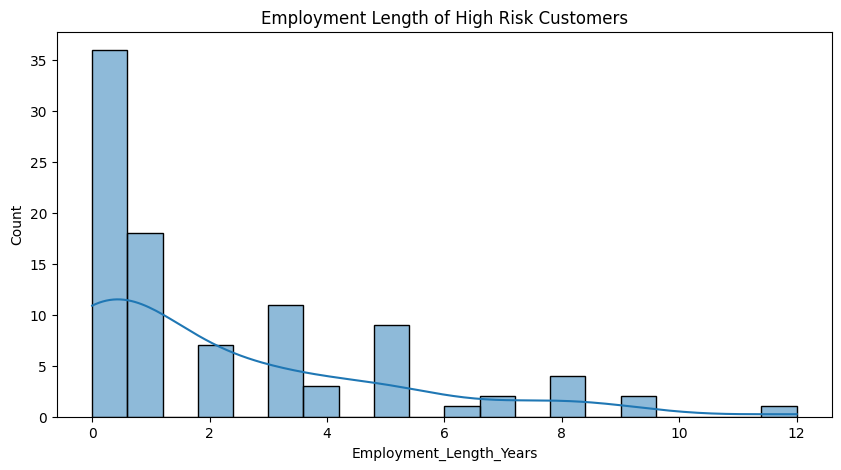

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(

    high_risk["Employment_Length_Years"],

    bins=20,

    kde=True

)

plt.title("Employment Length of High Risk Customers")

plt.show()

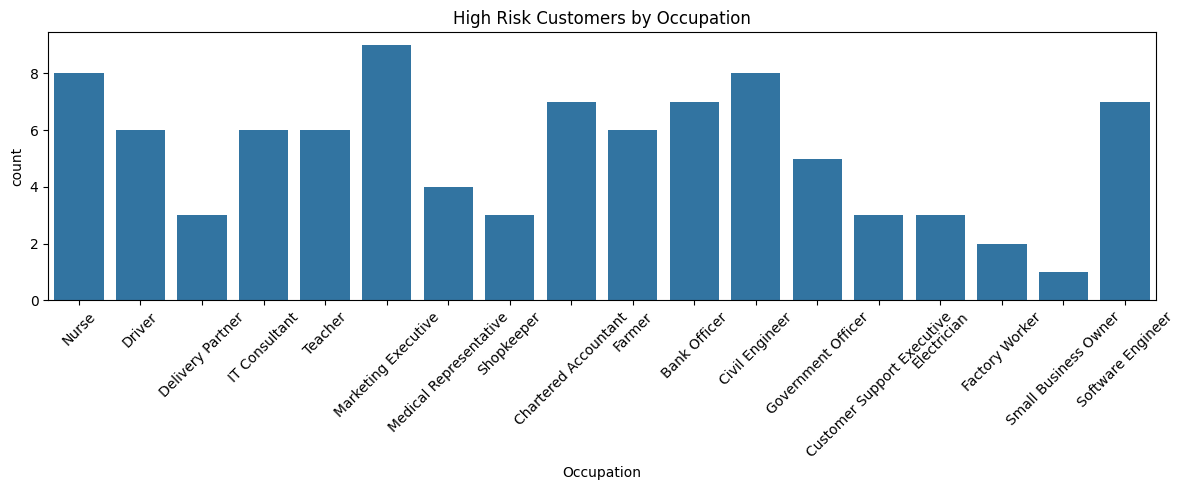

In [42]:
plt.figure(figsize=(12,5))

sns.countplot(

    data=high_risk,

    x="Occupation"

)

plt.xticks(rotation=45)

plt.title("High Risk Customers by Occupation")

plt.tight_layout()

plt.show()

## 12. Save Best Model

Persist the best-performing model to `models/risk_model.pkl` using `joblib`.

In [43]:
save_model(best_rf, "../models/risk_model.pkl")

Model saved → ../models/risk_model.pkl
